# Regresión lineal: Estudio de Power Laws

En este notebook vamos a usar **regresión lineal** para estudiar dos patrones sorprendentes que aparecen en sistemas muy distintos del mundo real: el **lenguaje humano** y los **terremotos**

Aunque parecen fenómenos completamente diferentes, ambos siguen **regularidades estadísticas muy similares**.

## Ley de zipf


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
from collections import Counter

### Cargamos los datos

Empezamos leyendo un conjunto de textos desde un archivo CSV. Cada fila contiene un fragmento de texto que usaremos para construir nuestro corpus de palabras.

Después mostramos las primeras filas para comprobar que los datos se han cargado correctamente y entender qué estructura tienen.

In [8]:
df = pd.read_csv("https://raw.githubusercontent.com/Jorgeprevi/ML_bootcamp_2026/refs/heads/main/regresion_lineal/textos.csv")
df.head()

,id,text,author
0,id26305,"This process, however, afforded me no means of...",EAP
1,id17569,It never once occurred to me that the fumbling...,HPL
2,id11008,"In his left hand was a gold snuff box, from wh...",EAP
3,id27763,How lovely is spring As we looked from Windsor...,MWS
4,id12958,"Finding nothing else, not even gold, the Super...",HPL


### Limpiamos los signos de puntuación

Antes de contar palabras, conviene limpiar un poco el texto. En este paso eliminamos signos de puntuación como comas, puntos, paréntesis o comillas.

¿Por qué hacemos esto? Porque, si no limpiamos, palabras como `mundo` y `mundo,` se considerarían distintas, y eso distorsionaría el análisis de frecuencias.

In [9]:
def remove_punctuations(input_col):
    """Función para eliminar los signos de puntuación de una columna de texto"""
    table = str.maketrans('','',string.punctuation)
    return input_col.translate(table)

df['text'] = df['text'].apply(remove_punctuations)

### Construimos el corpus completo

Ahora unimos todos los textos en una única cadena larga. A eso lo llamaremos **corpus**.

Además, convertimos todo a minúsculas para evitar duplicados artificiales. Por ejemplo, `Python` y `python` deberían contarse como la misma palabra.

In [10]:
def build_corpus(text_col):
    """construye un corpus de texto a partir de una columna de texto"""
    corpus = ""
    for sent in text_col:
        corpus += sent
    return corpus

corpus = build_corpus(df['text'])
corpus = corpus.lower()

corpus[:1000]

'this process however afforded me no means of ascertaining the dimensions of my dungeon as i might make its circuit and return to the point whence i set out without being aware of the fact so perfectly uniform seemed the wallit never once occurred to me that the fumbling might be a mere mistakein his left hand was a gold snuff box from which as he capered down the hill cutting all manner of fantastic steps he took snuff incessantly with an air of the greatest possible self satisfactionhow lovely is spring as we looked from windsor terrace on the sixteen fertile counties spread beneath speckled by happy cottages and wealthier towns all looked as in former years heart cheering and fairfinding nothing else not even gold the superintendent abandoned his attempts but a perplexed look occasionally steals over his countenance as he sits thinking at his deska youth passed in solitude my best years spent under your gentle and feminine fosterage has so refined the groundwork of my character that

### Separamos el texto en palabras

Una vez tenemos el corpus completo, lo dividimos en palabras individuales.

Este proceso se llama **tokenización** de forma muy básica: transformamos un texto largo en una lista de palabras. Así ya podremos contar cuántas veces aparece cada una.

In [11]:
corpus = corpus.split()
print(corpus[:50])

['this', 'process', 'however', 'afforded', 'me', 'no', 'means', 'of', 'ascertaining', 'the', 'dimensions', 'of', 'my', 'dungeon', 'as', 'i', 'might', 'make', 'its', 'circuit', 'and', 'return', 'to', 'the', 'point', 'whence', 'i', 'set', 'out', 'without', 'being', 'aware', 'of', 'the', 'fact', 'so', 'perfectly', 'uniform', 'seemed', 'the', 'wallit', 'never', 'once', 'occurred', 'to', 'me', 'that', 'the', 'fumbling', 'might']


### Contamos frecuencias y ordenamos las palabras

En este paso contamos cuántas veces aparece cada palabra en el corpus y las ordenamos de mayor a menor frecuencia.

También definimos algunos parámetros útiles:

- `top_n`: cuántas palabras frecuentes mostraremos en la gráfica.
- `min_count`: frecuencia mínima para conservar una palabra.
- `fit_max_rank`: hasta qué rango de palabras usaremos para ajustar la ley de Zipf.

Esta preparación es clave para poder estudiar si la distribución de frecuencias sigue el patrón esperado.

In [ ]:
top_n = 15  # número de palabras más comunes a mostrar en el barplot
min_count = 1  # frecuencia mínima de aparición para incluir una palabra en el análisis
fit_max_rank = 5000 # rango máximo para el ajuste de Zipf

# 1) Contar y ordenar
counts = Counter(corpus)
items = sorted(counts.items(), key=lambda x: x[1], reverse=True)

# Filtrado por frecuencia mínima de aparición
items = [(w, c) for (w, c) in items if c >= min_count]

### Visualizamos las palabras más frecuentes

Primero hacemos una gráfica de barras con las palabras más repetidas del corpus.

Esta visualización es una forma intuitiva de ver qué vocabulario domina en los textos. Normalmente observaremos que unas pocas palabras aparecen muchísimas veces, mientras que el resto son mucho menos frecuentes.

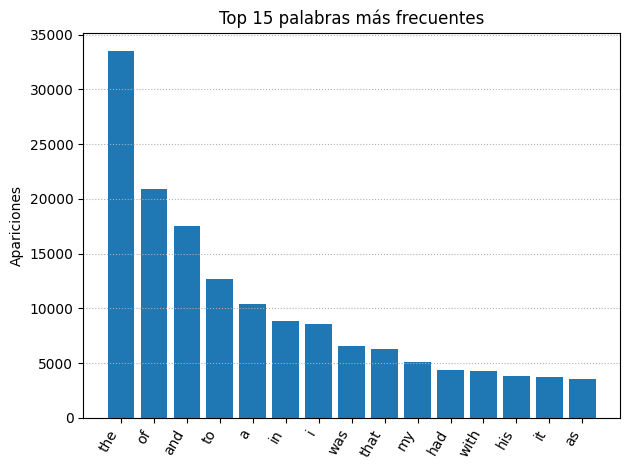

In [ ]:
# mostramos frecuencia de las palabras más comunes
top_n = min(top_n, len(items))
top_words = [w for (w, _) in items[:top_n]]
top_counts = [c for (_, c) in items[:top_n]]
plt.figure()
plt.bar(range(top_n), top_counts)
plt.xticks(range(top_n), top_words, rotation=60, ha="right")
plt.ylabel("Apariciones")
plt.title(f"Top {top_n} palabras más frecuentes")
plt.grid(True, axis="y", linestyle=":")
plt.tight_layout()
plt.show()

### Comprobamos la ley de Zipf

La **ley de Zipf** dice, de forma aproximada, que la frecuencia de una palabra es inversamente proporcional a su posición en el ranking. Es decir:

- la palabra más frecuente aparece mucho,
- la segunda aparece aproximadamente la mitad,
- la tercera en torno a un tercio
- y así sucesivamente.

Para comprobarlo:

1. construimos el ranking de palabras,
2. representamos frecuencia frente a rango en escala logarítmica,
3. ajustamos una recta en el espacio log-log.

Si los datos siguen razonablemente una línea recta en esta escala, eso es una señal de que la ley de Zipf describe bien el corpus. Además, mostramos el exponente estimado y un valor de \(R^2\) para medir qué tal encaja el ajuste.

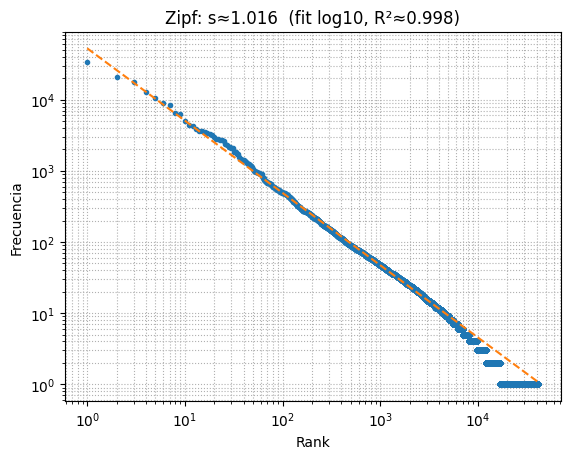

In [ ]:
# preparamos arrays rank/freq para Zipf
freqs = np.array([c for (_, c) in items], dtype=float)
ranks = np.arange(1, len(freqs) + 1, dtype=float)

# Tramo para el fit, teniendo en cuenta fit_max_rank
if fit_max_rank is not None:
    m = ranks <= float(fit_max_rank)
    r_fit = ranks[m]
    f_fit = freqs[m]
else:
    r_fit = ranks
    f_fit = freqs

# pasamos las variables a escala logarítmica para el ajuste lineal
x = np.log10(r_fit)
y = np.log10(f_fit)

# ajuste lineal en logspace: y = a + b x  => s = -b
b, a = np.polyfit(x, y, 1)

# obtenemos parámetros del modelo Zipf: f(r) = C * r^(-s)
s_hat = -b
C_hat = 10 ** a

# R² en espacio log
y_pred = a + b * x
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


plt.figure()
plt.loglog(ranks, freqs, marker=".", linestyle="none")
f_model = C_hat * (ranks ** (-s_hat)) # curva teórica ajustada
plt.loglog(ranks, f_model, linestyle="--")
plt.xlabel("Rank")
plt.ylabel("Frecuencia")
plt.title(f"Zipf: s≈{s_hat:.3f}  (fit log10, R²≈{r2:.3f})")
plt.grid(True, which="both", linestyle=":")
plt.show()

## Terremotos en Granada

### Cargamos los datos de terremotos

Ahora vamos a analizar un fenómeno completamente distinto al lenguaje: los **terremotos**.

En este caso cargamos un dataset con terremotos registrados en la zona de Granada entre 2019 y hoy. Entre las columnas del dataset hay una especialmente importante para nosotros: la **magnitud** del terremoto.

La magnitud mide la energía liberada por el terremoto, y será la variable clave para comprobar una famosa relación empírica en sismología: **la ley de Gutenberg-Richter**.

In [ ]:
df_terremotos = pd.read_csv("https://raw.githubusercontent.com/Jorgeprevi/ML_bootcamp_2026/refs/heads/main/regresion_lineal/terremotos_granada.csv", sep = ";")
df_terremotos.head()

,Evento,Fecha,Hora,Latitud,Longitud,Prof,Inten,Mag,TipoMag,Localizacion
0,es2018dpbji,02/04/2018,04:45:59,36.8871,-3.7176,10.0,,1.6,4,NW LENTEGÍ.GR
1,es2018dpeam,02/04/2018,10:05:22,37.1579,-3.6927,12.0,II,2.7,4,W CÚLLAR VEGA.GR
2,es2018dphbk,02/04/2018,16:42:26,37.2332,-3.6958,0.0,,1.3,4,NW ATARFE.GR
3,es2018dpogd,03/04/2018,08:30:23,36.8632,-2.8686,10.0,,1.8,4,N DALÍAS.AL
4,es2018eajhk,04/04/2018,08:32:39,36.8522,-2.9145,16.0,,1.9,4,E BERJA.AL


### Comprobamos la ley de Gutenberg–Richter

La **ley de Gutenberg–Richter** describe cómo se distribuyen los terremotos según su magnitud. De forma simplificada, dice que:

\[
\log_{10}(N(M \ge m)) = a - b \cdot m
\]

donde:

- \(M\) es la magnitud del terremoto  
- \(N(M \ge m)\) es el número de terremotos con magnitud mayor o igual que \(m\)  
- \(a\) y \(b\) son constantes que dependen de la región  

La interpretación es muy intuitiva:

- Los terremotos **pequeños son muy frecuentes**
- Los terremotos **grandes son mucho más raros**

En este código hacemos varios pasos:

1. **Limpiamos las magnitudes** del dataset.
2. **Agrupamos las magnitudes en bins** (intervalos).
3. Calculamos el **número acumulado de terremotos con magnitud ≥ m**.
4. Aplicamos **logaritmo en base 10** al número de eventos.
5. Ajustamos una **regresión lineal** para estimar la relación.

Si los datos siguen la ley de Gutenberg–Richter, veremos que los puntos se alinean aproximadamente en una **recta**, y podremos estimar el parámetro **b**, que describe cómo decrece la frecuencia de terremotos al aumentar la magnitud.

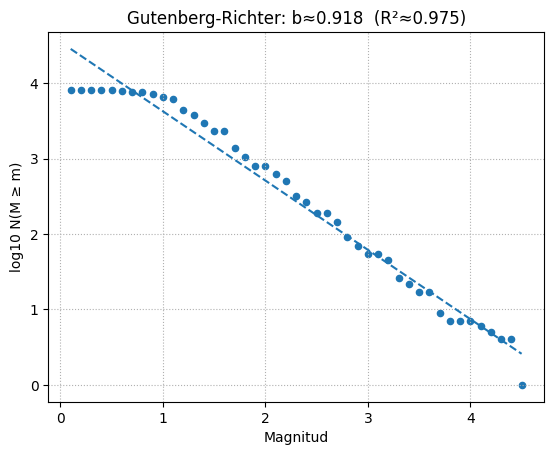

In [ ]:
bin_width = 0.1      # resolución de magnitud

# Limpiamos nulos
mags = df_terremotos["Mag"].dropna().astype(float).values

# Creamos bins de magnitud (entre mínimo y máximo)
m_min = np.floor(mags.min()*10)/10
m_max = np.ceil(mags.max()*10)/10

bins = np.arange(m_min, m_max + bin_width, bin_width)

# Contamos medidas acumuladas para cada bin
hist, edges = np.histogram(mags, bins=bins)

# mostramos en cada bin la cantidad de terremotos con magnitud mayor o igual, N(M >= m)
cum_counts = np.cumsum(hist[::-1])[::-1]

magnitudes = edges[:-1]

M_fit = magnitudes
N_fit = cum_counts

x = M_fit
y = np.log10(N_fit)

# Ajuste lineal
b_slope, a_intercept = np.polyfit(x, y, 1)

b_value = -b_slope
a_value = a_intercept

# R²
y_pred = a_intercept + b_slope * x
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

# Mostramos la figura con los datos reales y el modelo ajustado
plt.figure()

plt.scatter(magnitudes, np.log10(cum_counts), s=20)

x_model = np.linspace(magnitudes.min(), magnitudes.max(), 200)
y_model = a_intercept + b_slope * x_model

plt.plot(x_model, y_model, linestyle="--")

plt.xlabel("Magnitud")
plt.ylabel("log10 N(M ≥ m)")
plt.title(f"Gutenberg-Richter: b≈{b_value:.3f}  (R²≈{r2:.3f})")

plt.grid(True, linestyle=":")
plt.show()